In [173]:
import os
import time
from datetime import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import torchvision
from tensorflow.keras.models import load_model

In [174]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, Callback
import tensorflow.keras.backend as K

In [175]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

In [176]:
X_train = train_dataset.data
y_train = np.array(train_dataset.targets)
X_test = test_dataset.data
y_test = np.array(test_dataset.targets)

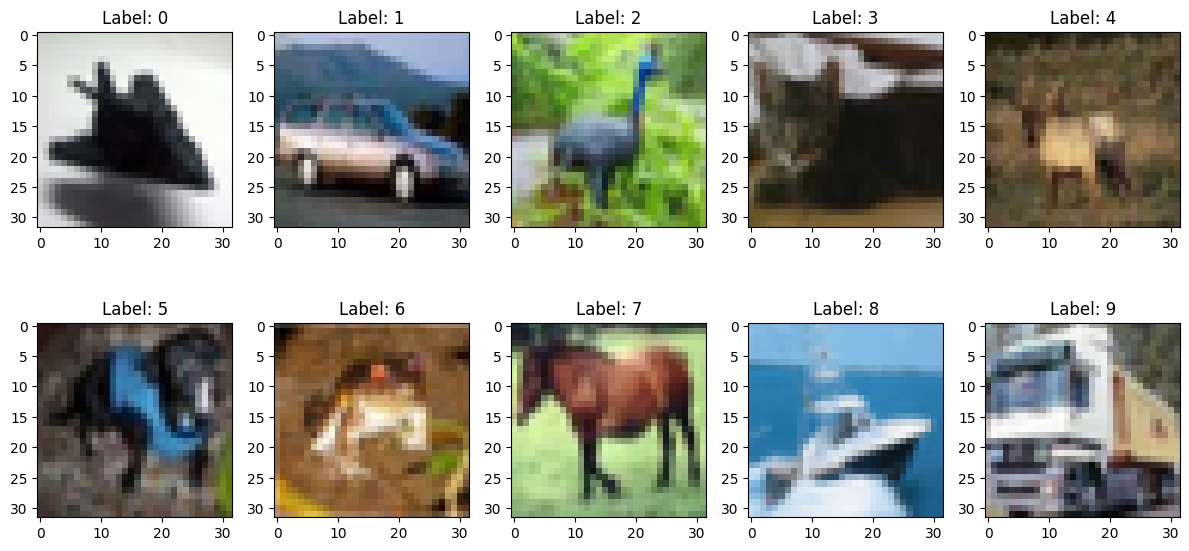

In [177]:
unique_labels = np.unique(y_train)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, label in enumerate(unique_labels):
    idx = np.where(y_train == label)[0][0]
    ax = axes[i]
    ax.imshow(X_train[idx])
    ax.set_title(f"Label: {label}")

plt.tight_layout()
plt.show()

In [178]:
# Shuffle the data
train_indices = np.arange(len(X_train))
np.random.shuffle(train_indices)
X_train = X_train[train_indices]
y_train = y_train[train_indices]

test_indices = np.arange(len(X_test))
np.random.shuffle(test_indices)
X_test = X_test[test_indices]
y_test = y_test[test_indices]

In [179]:
# Normalize the images
X_train = X_train / 255.0
X_test = X_test / 255.0

In [180]:
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [181]:
# Reshape the images to add a channel dimension (grayscale: 3 channel)
X_train = X_train.reshape(-1, 32, 32, 3)
X_test = X_test.reshape(-1, 32, 32, 3)

In [182]:
# # Convert labels to categorical (Multi class classification)
# y_train = to_categorical(y_train, num_classes=10)
# y_test = to_categorical(y_test, num_classes=10)

In [183]:
y_train

array([9, 6, 9, ..., 8, 6, 5])

In [184]:
# Build the CNN model
model = Sequential(
    [
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    #Dropout(0.5),
    Dense(10, activation='softmax')
]
    )

In [185]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,506 (759.79 KB)

 Trainable params: 194,506 (759.79 KB)

 Non-trainable params: 0 (0.00 B)

In [186]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [187]:
es1 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=True)
cp1 = ModelCheckpoint("best_model1.keras", monitor='val_loss', save_best_only=True, verbose=1)

In [188]:
history = model.fit(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[es1, cp1], verbose=1)

Epoch 1/50
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3210 - loss: 1.8193
Epoch 1: val_loss improved from inf to 1.24421, saving model to best_model1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3216 - loss: 1.8180 - val_accuracy: 0.5484 - val_loss: 1.2442
Epoch 2/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5692 - loss: 1.2037
Epoch 2: val_loss improved from 1.24421 to 1.13545, saving model to best_model1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5693 - loss: 1.2036 - val_accuracy: 0.5983 - val_loss: 1.1355
Epoch 3/50
1245/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6453 - loss: 1.0079
Epoch 3: val_loss improved from 1.13545 to 0.98338, saving model to best_model1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6453 - loss: 1.0078 - val_accuracy: 0.6576 - val_loss: 0.9834
Epoch 4/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6898 - loss: 0.8779
Epoch 4: val_loss improved from 0.98

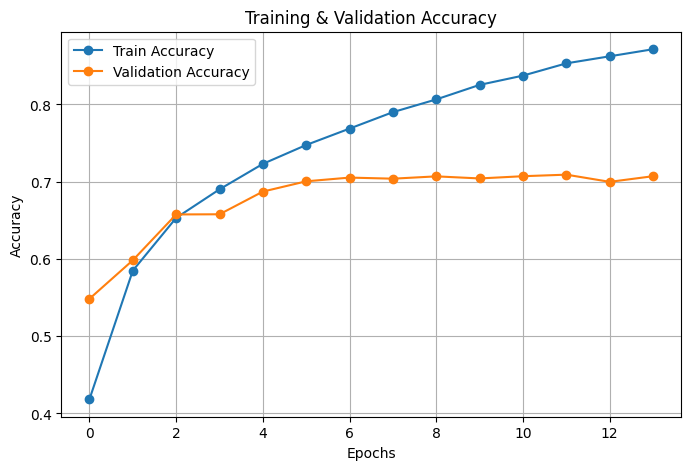

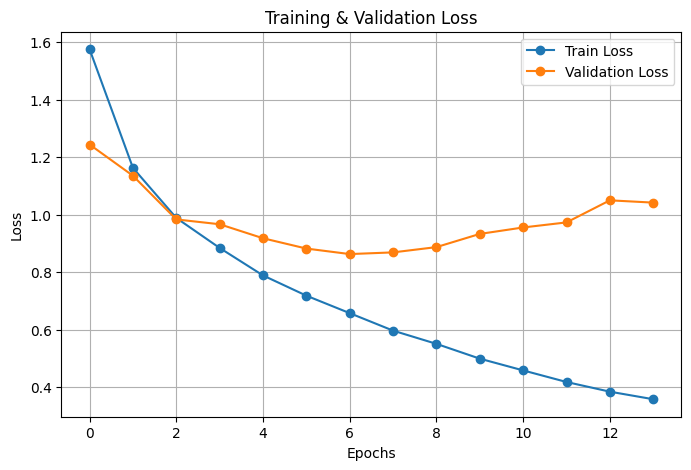

In [189]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

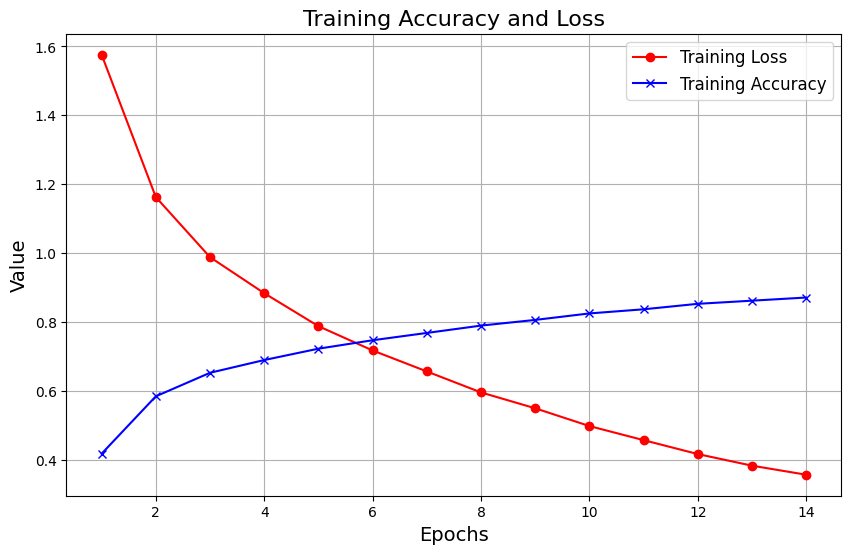

In [190]:
def plot_training_curves_combined(history):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(history.history['loss']) + 1)

    # Plot loss
    plt.plot(epochs, history.history['loss'], label="Training Loss", color="red", marker="o")

    # Plot accuracy
    plt.plot(epochs, history.history['accuracy'], label="Training Accuracy", color="blue", marker="x")

    plt.title("Training Accuracy and Loss", fontsize=16)
    plt.xlabel("Epochs", fontsize=14)
    plt.ylabel("Value", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

plot_training_curves_combined(history)

In [191]:
model1 = load_model("best_model1.keras")
test_loss, test_acc = model1.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7050 - loss: 0.8593
Test accuracy: 0.7016


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


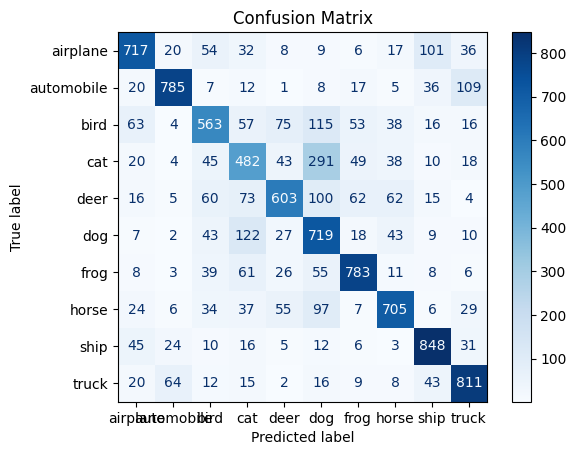

In [192]:
# Predict on the test set
y_pred = model1.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get predicted class labels
y_true_classes = y_test # Get true class labels

# Generate confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [193]:
# Generate classification report
print("Classification Report:")
report = classification_report(y_true_classes, y_pred_classes, target_names=train_dataset.classes)
print(report)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.76      0.72      0.74      1000
  automobile       0.86      0.79      0.82      1000
        bird       0.65      0.56      0.60      1000
         cat       0.53      0.48      0.51      1000
        deer       0.71      0.60      0.65      1000
         dog       0.51      0.72      0.59      1000
        frog       0.78      0.78      0.78      1000
       horse       0.76      0.70      0.73      1000
        ship       0.78      0.85      0.81      1000
       truck       0.76      0.81      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



In [194]:
train_dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [195]:
y_test

array([8, 9, 8, ..., 8, 7, 5])

In [196]:
y_pred_classes

array([8, 9, 8, ..., 8, 7, 5])

<BarContainer object of 50000 artists>

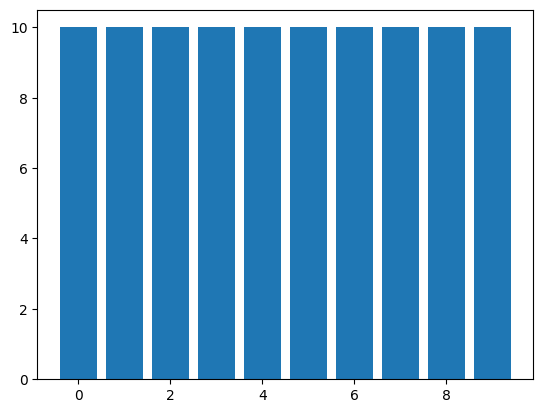

In [197]:
plt.bar(y_train,height=10)